In [13]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# PyTorch
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Sklearn (for visualization later)
from sklearn.model_selection import train_test_split

# Device setup (GPU if available)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [14]:
train_df = pd.read_csv("emnist-balanced-train.csv", header=None)
test_df = pd.read_csv("emnist-balanced-test.csv", header=None)

print(train_df.shape)

(112800, 785)


In [15]:
y_train = train_df.iloc[:,0].values
X_train = train_df.iloc[:,1:].values

y_test = test_df.iloc[:,0].values
X_test = test_df.iloc[:,1:].values


In [16]:
X_train = X_train/255.0
X_test = X_test/255.0

In [17]:
def fix_rotation(X):
    X = X.reshape(-1, 28, 28)
    
    X = np.rot90(X, k=1, axes=(1, 2))  # 90° clockwise
    X = np.fliplr(X)                   # mirror (horizontal flip)
    
      
    
    return X

X_train=fix_rotation(X_train)
X_test = fix_rotation(X_test)

In [18]:
X_train = X_train.reshape(-1,28*28)
X_test = X_test.reshape(-1,28*28)

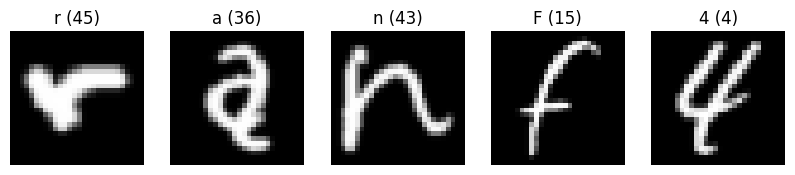

In [19]:
mapping = {}

with open("emnist-balanced-mapping.txt") as f:
    for line in f:
        label, ascii_code = map(int, line.strip().split())
        mapping[label] = chr(ascii_code)


def show_images(X, y, n=5):
    plt.figure(figsize=(10, 2))
    
    for i in range(n):
        plt.subplot(1, n, i+1)
        img = X[i].reshape(28, 28)
        plt.imshow(img, cmap='gray')
        
        label = int(y[i])
        char = mapping[label]
        
        plt.title(f"{char} ({label})")
        plt.axis('off')
    
    plt.show()

show_images(X_train, y_train, n=5)

In [20]:
X_train = torch.tensor(X_train, dtype=torch.float32).to(device)
X_test = torch.tensor(X_test, dtype=torch.float32).to(device)

In [21]:


class AE_ANN_1(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Linear(128, 64)   # bottleneck
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Linear(128, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid()
        )
    
    def forward(self, x):
        return self.decoder(self.encoder(x))

In [22]:

train_dataset = TensorDataset(X_train, X_train)
test_dataset = TensorDataset(X_test, X_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

In [23]:
model = AE_ANN_1().to(device)

criterion = nn.MSELoss()   # reconstruction loss
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [24]:
train_losses = []
val_losses = []

for epoch in range(5):
    model.train()
    train_loss = 0
    
    for X_batch, _ in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, X_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    
    train_loss /= len(train_loader)  # fixed normalization too
    
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, _ in test_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, X_batch)
            val_loss += loss.item()
    
    val_loss /= len(test_loader)  # fixed normalization too
    
    train_losses.append(train_loss)
    val_losses.append(val_loss)
    
    print(f"Epoch {epoch+1} | Train: {train_loss:.4f} | Val: {val_loss:.4f}")

Epoch 1 | Train: 0.0360 | Val: 0.0183
Epoch 2 | Train: 0.0150 | Val: 0.0128
Epoch 3 | Train: 0.0116 | Val: 0.0108
Epoch 4 | Train: 0.0098 | Val: 0.0092
Epoch 5 | Train: 0.0086 | Val: 0.0083


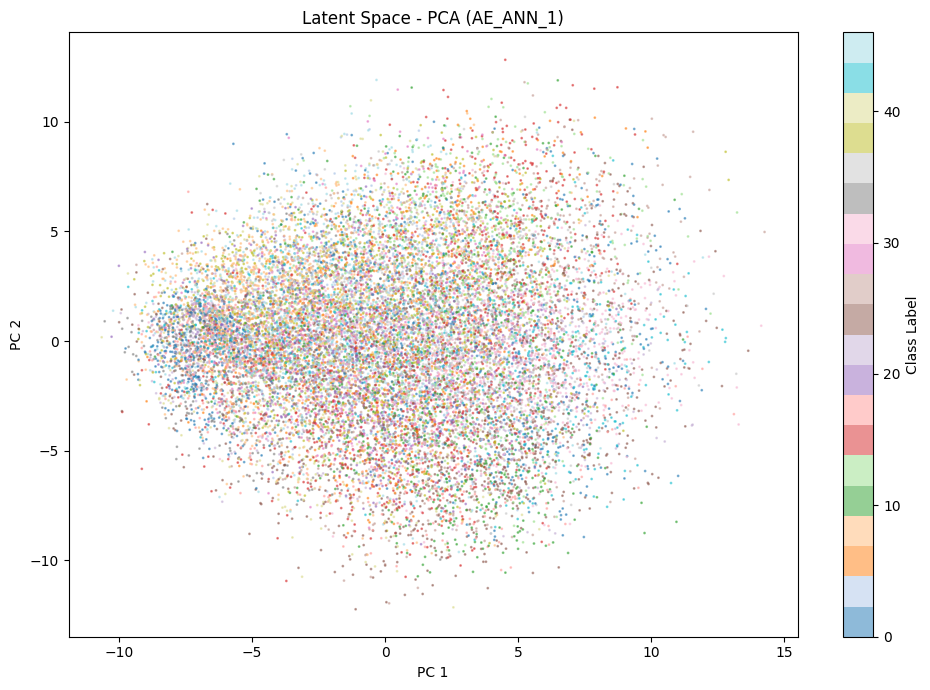

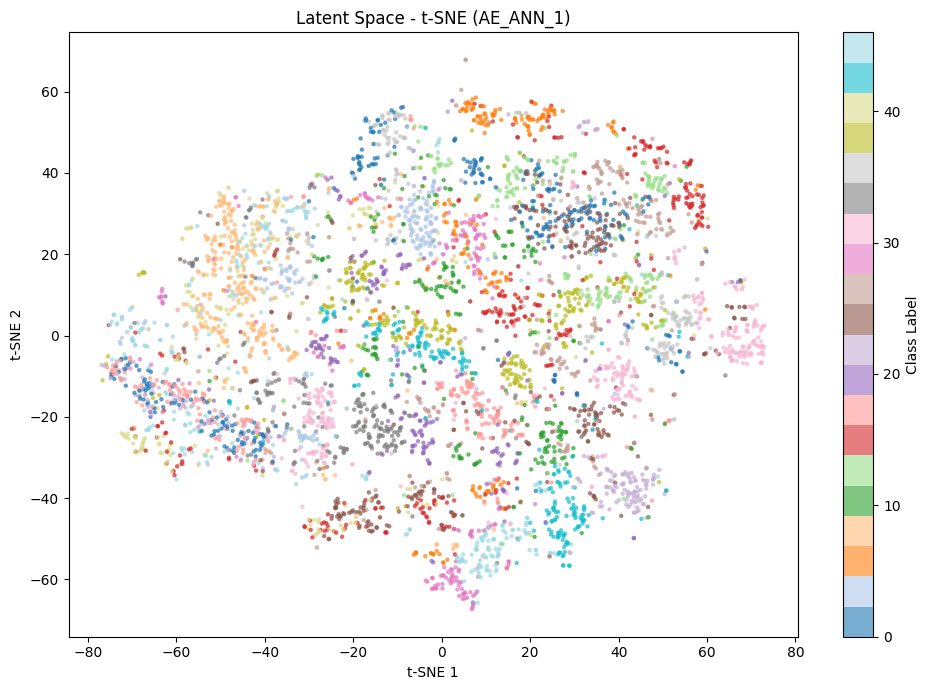

In [25]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

# 1. Extract latent vectors
model.eval()
with torch.no_grad():
    latent = model.encoder(X_test)  # shape: (N, 64)

latent_np = latent.cpu().numpy()
labels_np = y_test  # class labels for coloring

# 2. PCA plot (fast)
pca = PCA(n_components=2)
latent_2d = pca.fit_transform(latent_np)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(latent_2d[:, 0], latent_2d[:, 1], 
                      c=labels_np, cmap='tab20', s=1, alpha=0.5)
plt.colorbar(scatter, label='Class Label')
plt.title("Latent Space - PCA (AE_ANN_1)")
plt.xlabel("PC 1")
plt.ylabel("PC 2")
plt.tight_layout()
plt.show()

# 3. t-SNE plot (slower but better separation)
# Use a subset to keep it fast
subset = 5000
tsne = TSNE(n_components=2, random_state=42, perplexity=30)
latent_tsne = tsne.fit_transform(latent_np[:subset])

plt.figure(figsize=(10, 7))
scatter = plt.scatter(latent_tsne[:, 0], latent_tsne[:, 1],
                      c=labels_np[:subset], cmap='tab20', s=5, alpha=0.6)
plt.colorbar(scatter, label='Class Label')
plt.title("Latent Space - t-SNE (AE_ANN_1)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
plt.tight_layout()
plt.show()

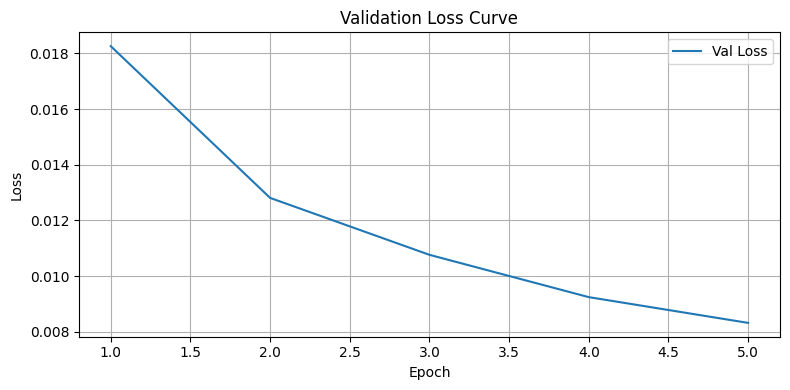

In [26]:
plt.figure(figsize=(8, 4))

plt.plot(range(1, len(val_losses)+1), val_losses, label="Val Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Validation Loss Curve")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

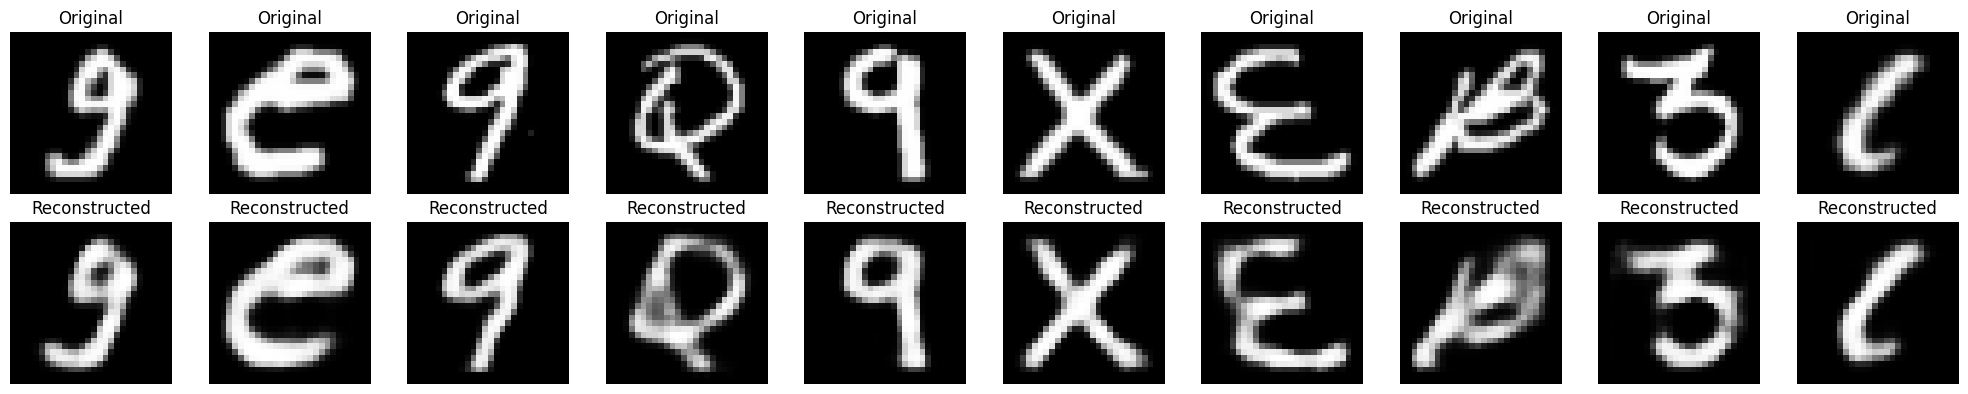

In [30]:
def show_reconstruction(model, X, n=10):
    model.eval()
    
    with torch.no_grad():
        recon = model(X[:n])
    
    plt.figure(figsize=(2*n, 4))
    
    for i in range(n):
        # Original
        plt.subplot(2, n, i+1)
        plt.imshow(X[i].cpu().reshape(28,28), cmap='gray')
        plt.title("Original")
        plt.axis('off')
        
        # Reconstructed
        plt.subplot(2, n, i+n+1)
        plt.imshow(recon[i].cpu().reshape(28,28), cmap='gray')
        plt.title("Reconstructed")
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()
    
show_reconstruction(model, X_test, n=10)   # 10 samples
